In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_regression

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score, classification_report, confusion_matrix
from scipy.stats import randint as sp_randint

import shap
import joblib

In [2]:
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid', palette='muted')

# Data Loading and Inspection

In [3]:
df_gym= pd.read_csv('data/1. Gym Members Exercise Dataset/gym_members_exercise_tracking.csv')
df_fit = pd.read_csv('data/2. Exercise and Fitness Metrics Dataset/exercise_dataset.csv')
df_excise= pd.read_csv('data/3. Fitness Exercises Dataset/exercises_flat.csv')
df_rec = pd.read_excel('data/4. Mendeley Gym Recommendation Dataset/gym recommendation.xlsx')

print("Columns in gym_members_exercise_tracking.csv:", df_gym.columns.tolist())
print("Columns in exercise_dataset.csv:", df_fit.columns.tolist())
print("Columns in exercises_flat.csv:", df_excise.columns.tolist())
print("Columns in gym recommendation.xlsx:", df_rec.columns.tolist())

print()

print(f'Dataset 1 (Gym Members)          : {df_gym.shape[0]:,} rows × {df_gym.shape[1]} cols')
print(f'Dataset 2 (Exercise & Fitness)   : {df_fit.shape[0]:,} rows × {df_fit.shape[1]} cols')
print(f'Dataset 3 (Exercise Library)     : {df_excise.shape[0]:,} rows × {df_excise.shape[1]} cols')
print(f'Dataset 4 (Mendeley Coaching)    : {df_rec.shape[0]:,} rows × {df_rec.shape[1]} cols')
print()

Columns in gym_members_exercise_tracking.csv: ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']
Columns in exercise_dataset.csv: ['ID', 'Exercise', 'Calories Burn', 'Dream Weight', 'Actual Weight', 'Age', 'Gender', 'Duration', 'Heart Rate', 'BMI', 'Weather Conditions', 'Exercise Intensity']
Columns in exercises_flat.csv: ['exerciseId', 'name', 'gifUrl', 'target_muscles', 'body_part_category', 'equipment_needed', 'secondaryMuscles', 'instructions']
Columns in gym recommendation.xlsx: ['ID', 'Sex', 'Age', 'Height', 'Weight', 'Hypertension', 'Diabetes', 'BMI', 'Level', 'Fitness Goal', 'Fitness Type', 'Exercises', 'Equipment', 'Diet', 'Recommendation']

Dataset 1 (Gym Members)          : 973 rows × 15 cols
Dataset 2 (Exercise & Fitness)   : 3,864 rows × 12 cols
Dataset 3 (Exercise Library)    

In [4]:
print(df_gym.head(3).to_string())


   Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  Session_Duration (hours)  Calories_Burned Workout_Type  Fat_Percentage  Water_Intake (liters)  Workout_Frequency (days/week)  Experience_Level    BMI
0   56    Male         88.3        1.71      180      157           60                      1.69           1313.0         Yoga            12.6                    3.5                              4                 3  30.20
1   46  Female         74.9        1.53      179      151           66                      1.30            883.0         HIIT            33.9                    2.1                              4                 2  32.00
2   32  Female         68.1        1.66      167      122           54                      1.11            677.0       Cardio            33.4                    2.3                              4                 2  24.71


In [5]:
print(df_fit.head(3).to_string())

   ID    Exercise  Calories Burn  Dream Weight  Actual Weight  Age Gender  Duration  Heart Rate        BMI Weather Conditions  Exercise Intensity
0   1  Exercise 2     286.959851     91.892531      96.301115   45   Male        37         170  29.426275              Rainy                   5
1   2  Exercise 7     343.453036     64.165097      61.104668   25   Male        43         142  21.286346              Rainy                   5
2   3  Exercise 4     261.223465     70.846224      71.766724   20   Male        20         148  27.899592             Cloudy                   4


In [6]:
print(df_excise.head(3).to_string())

  exerciseId                            name       gifUrl target_muscles body_part_category equipment_needed                secondaryMuscles                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      instructions
0    2ORFMoR                 hack calf raise  2ORFMoR.gif         calves         lower legs     sled machine              hamstrings; glutes                                                                                                                                           St

In [7]:
print(df_rec.head(3).to_string())

   ID   Sex  Age  Height  Weight Hypertension Diabetes    BMI        Level Fitness Goal      Fitness Type                                                     Exercises                                                     Equipment                                                                                                                                                                                                                      Diet                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [8]:
for label, df in [("D1 Gym Members", df_gym), ("D2 Fitness", df_fit),("D3 Exercises", df_excise), ("D4 Recommendation", df_rec)]:
    missing = df.isnull().sum()
    has_missing = missing[missing > 0]
    if len(has_missing):
        print(f"\n{label}:\n{has_missing}")
    else:
        print(f"{label}: No missing values")

D1 Gym Members: No missing values
D2 Fitness: No missing values
D3 Exercises: No missing values
D4 Recommendation: No missing values


In [9]:
print("\nDataset 1 (Gym Members) Descriptive Stats")
print(df_gym.describe().round(2).to_string())
 
print("\nDataset 2 (Fitness) Descriptive Stats")
print(df_fit.describe().round(2).to_string())

print("\nDataset 3 (Exercises) Descriptive Stats")
print(df_excise.describe().round(2).to_string())

print("\nDataset 4 (Recommendation) Descriptive Stats")
print(df_rec.describe().round(2).to_string())


Dataset 1 (Gym Members) Descriptive Stats
          Age  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  Session_Duration (hours)  Calories_Burned  Fat_Percentage  Water_Intake (liters)  Workout_Frequency (days/week)  Experience_Level     BMI
count  973.00       973.00      973.00   973.00   973.00       973.00                    973.00           973.00          973.00                 973.00                         973.00            973.00  973.00
mean    38.68        73.85        1.72   179.88   143.77        62.22                      1.26           905.42           24.98                   2.63                           3.32              1.81   24.91
std     12.18        21.21        0.13    11.53    14.35         7.33                      0.34           272.64            6.26                   0.60                           0.91              0.74    6.66
min     18.00        40.00        1.50   160.00   120.00        50.00                      0.50           303.00         

In [10]:
print("Dataset 1 (Gym Members) Info:")
df_gym.info()

print("\nDataset 2 (Fitness) Info:")
df_fit.info()

print("\nDataset 3 (Exercises) Info:")
df_excise.info()

print("\nDataset 4 (Recommendation) Info:")
df_rec.info()

Dataset 1 (Gym Members) Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (d

In [11]:
df_gym.head(3)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71


In [12]:
df_gym.head(3)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71


In [13]:
df_excise.head(3)

,exerciseId,name,gifUrl,target_muscles,body_part_category,equipment_needed,secondaryMuscles,instructions
0,2ORFMoR,hack calf raise,2ORFMoR.gif,calves,lower legs,sled machine,hamstrings; glutes,Step:1 Adjust the sled machine to a comfortabl...
1,2Qh2J1e,sled 45Â° leg press (side pov),2Qh2J1e.gif,glutes,upper legs,sled machine,quadriceps; hamstrings; calves,Step:1 Adjust the seat of the sled machine so ...
2,3eGE2JC,dumbbell front raise,3eGE2JC.gif,delts,shoulders,dumbbell,biceps; trapezius,Step:1 Stand with your feet shoulder-width apa...


In [14]:
df_rec.head(3)

,ID,Sex,Age,Height,Weight,Hypertension,Diabetes,BMI,Level,Fitness Goal,Fitness Type,Exercises,Equipment,Diet,Recommendation
0,1,Male,18,1.68,47.5,No,No,16.83,Underweight,Weight Gain,Muscular Fitness,"Squats, deadlifts, bench presses, and overhead...",Dumbbells and barbells,"Vegetables: (Carrots, Sweet Potato, and Lettuc...",Follow a regular exercise schedule. Adhere to ...
1,2,Male,18,1.68,47.5,Yes,No,16.83,Underweight,Weight Gain,Muscular Fitness,"Squats, deadlifts, bench presses, and overhead...","Light athletic shoes, resistance bands, and li...","Vegetables: (Tomatoes, Garlic, leafy greens, b...",Follow a regular exercise schedule. Adhere to ...
2,3,Male,18,1.68,47.5,No,Yes,16.83,Underweight,Weight Gain,Muscular Fitness,"Squats, yoga, deadlifts, bench presses, and ov...","Dumbbells, barbells and Blood glucose monitor","Vegetables: (Garlic, Roma Tomatoes, Capers and...",Follow a regular exercise schedule. Adhere to ...


# Data Preprocessing

In [15]:
df_fit_clean = df_fit.copy()

df_fit_clean.drop(columns=['ID', 'Exercise'], inplace=True)

df_fit_clean.rename(columns={
    'Calories Burn' : 'Calories_Burned',
    'Actual Weight' : 'Weight (kg)',
    'Dream Weight' : 'Dream_Weight',
    'Heart Rate' : 'Avg_BPM',
    'Weather Conditions' : 'Weather_Conditions',
    'Exercise Intensity' : 'Exercise_Intensity',
}, inplace=True)

df_fit_clean.rename(columns={'Duration': 'Session_Duration (hours)'}, inplace=True)
df_fit_clean['Session_Duration (hours)'] = df_fit_clean['Session_Duration (hours)'] / 60

#Adding new column name _source to dataset 1 and 2 to identify the source of data
df_gym['_source']      = 'ds1'
df_fit_clean['_source'] = 'ds2'

In [16]:
print('DS1 columns:', list(df_gym.columns))
print()
print('DS2 columns After CLeaning and Renaming:', list(df_fit_clean.columns))

DS1 columns: ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', '_source']

DS2 columns After CLeaning and Renaming: ['Calories_Burned', 'Dream_Weight', 'Weight (kg)', 'Age', 'Gender', 'Session_Duration (hours)', 'Avg_BPM', 'BMI', 'Weather_Conditions', 'Exercise_Intensity', '_source']


In [17]:
# pd.concat fills missing columns with NaN automatically
dfUnified = pd.concat([df_gym, df_fit_clean], ignore_index=True)

print(f'Merged DataFrame shape: {dfUnified.shape}')
print(f'  DS1 (gym data) rows: {(dfUnified["_source"]=="ds1").sum()}')
print(f'  DS2 (fit data) rows: {(dfUnified["_source"]=="ds2").sum()}')
print()
print('Missing values per column:')
print(dfUnified.isnull().sum().to_string())

Merged DataFrame shape: (4837, 19)
  DS1 (gym data) rows: 973
  DS2 (fit data) rows: 3864

Missing values per column:
Age                                 0
Gender                              0
Weight (kg)                         0
Height (m)                       3864
Max_BPM                          3864
Avg_BPM                             0
Resting_BPM                      3864
Session_Duration (hours)            0
Calories_Burned                     0
Workout_Type                     3864
Fat_Percentage                   3864
Water_Intake (liters)            3864
Workout_Frequency (days/week)    3864
Experience_Level                 3864
BMI                                 0
_source                             0
Dream_Weight                      973
Weather_Conditions                973
Exercise_Intensity                973


In [18]:
dfUnified.head(3)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,_source,Dream_Weight,Weather_Conditions,Exercise_Intensity
0,56,Male,88.3,1.71,180.0,157,60.0,1.69,1313.0,Yoga,12.6,3.5,4.0,3.0,30.20,ds1,NaN,NaN,NaN
1,46,Female,74.9,1.53,179.0,151,66.0,1.30,883.0,HIIT,33.9,2.1,4.0,2.0,32.00,ds1,NaN,NaN,NaN
2,32,Female,68.1,1.66,167.0,122,54.0,1.11,677.0,Cardio,33.4,2.3,4.0,2.0,24.71,ds1,NaN,NaN,NaN


In [19]:
#Training Random Forest Regressor for each column using dataset one then predict realistic values for dataset two

#First : DS1 only columns (train on DS1, predict for DS2)
IMPUTE_PREDICTORS = [
    'Age', 'Weight (kg)', 'BMI',
    'Avg_BPM', 'Session_Duration (hours)'
]

# Encode Gender temporarily just for imputation models
dfUnified['_g'] = (dfUnified['Gender'] == 'Male').astype(int)
imp_preds = IMPUTE_PREDICTORS + ['_g']

ds1_mask = dfUnified['_source'] == 'ds1'
ds2_mask = dfUnified['_source'] == 'ds2'

imputer_models = {} # save each model (needed to impute inference time data)
impute_report  = []

DS1_ONLY_COLS = [
    'Height (m)', 'Max_BPM', 'Resting_BPM',
    'Fat_Percentage', 'Water_Intake (liters)',
    'Workout_Frequency (days/week)', 'Experience_Level'
]

print('DS1-only columns (train on DS1, predict for DS2):\n')
for col in DS1_ONLY_COLS:
    missing_n = dfUnified[col].isnull().sum()
    if missing_n == 0:
        print(f'  {col:<42s} — no NaNs, skipped')
        continue

    X_known  = dfUnified.loc[ds1_mask, imp_preds]
    y_known  = dfUnified.loc[ds1_mask, col]
    X_miss   = dfUnified.loc[ds2_mask, imp_preds]

    imp_rf = RandomForestRegressor(
        n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
    )
    imp_rf.fit(X_known, y_known)
    train_r2 = imp_rf.score(X_known, y_known)
    cv_r2    = cross_val_score(
        imp_rf, X_known, y_known, cv=5, scoring='r2', n_jobs=-1
    ).mean()

    dfUnified.loc[ds2_mask, col] = imp_rf.predict(X_miss)
    imputer_models[col] = imp_rf
    impute_report.append({
        'Column': col, 'Direction': 'DS1→DS2',
        'Missing': missing_n,
        'Train R²': round(train_r2, 3),
        'CV R² (5-fold)': round(cv_r2, 3)
    })
    print(f'  {col:<42s} Train R²={train_r2:.3f}  CV R²={cv_r2:.3f}')

DS2_ONLY_COLS = ['Exercise_Intensity', 'Dream_Weight']

#Second : DS2 only columns (train on DS2, predict for DS1)
print('\nDS2-only columns (train on DS2, predict for DS1):\n')
for col in DS2_ONLY_COLS:
    missing_n = dfUnified[col].isnull().sum()
    if missing_n == 0:
        print(f'  {col:<42s} — no NaNs, skipped')
        continue

    X_known  = dfUnified.loc[ds2_mask, imp_preds]
    y_known  = dfUnified.loc[ds2_mask, col]
    X_miss   = dfUnified.loc[ds1_mask, imp_preds]

    imp_rf = RandomForestRegressor(
        n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
    )
    imp_rf.fit(X_known, y_known)
    train_r2 = imp_rf.score(X_known, y_known)
    cv_r2    = cross_val_score(
        imp_rf, X_known, y_known, cv=5, scoring='r2', n_jobs=-1
    ).mean()

    dfUnified.loc[ds1_mask, col] = imp_rf.predict(X_miss)
    imputer_models[col] = imp_rf
    impute_report.append({
        'Column': col, 'Direction': 'DS2→DS1',
        'Missing': missing_n,
        'Train R²': round(train_r2, 3),
        'CV R² (5-fold)': round(cv_r2, 3)
    })
    print(f'  {col:<42s} Train R²={train_r2:.3f}  CV R²={cv_r2:.3f}')

dfUnified.drop(columns=['_g'], inplace=True)

print()
print(pd.DataFrame(impute_report).to_string(index=False))
remaining = dfUnified.select_dtypes(include='number').isnull().sum().sum()
print(f'\nTotal remaining numeric NaNs: {remaining}')

DS1-only columns (train on DS1, predict for DS2):

  Height (m)                                 Train R²=0.996  CV R²=0.970
  Max_BPM                                    Train R²=0.557  CV R²=-0.074
  Resting_BPM                                Train R²=0.526  CV R²=-0.033
  Fat_Percentage                             Train R²=0.925  CV R²=0.794
  Water_Intake (liters)                      Train R²=0.843  CV R²=0.574
  Workout_Frequency (days/week)              Train R²=0.801  CV R²=0.470
  Experience_Level                           Train R²=0.875  CV R²=0.731

DS2-only columns (train on DS2, predict for DS1):

  Exercise_Intensity                         Train R²=0.276  CV R²=-0.022
  Dream_Weight                               Train R²=0.985  CV R²=0.963

                       Column Direction  Missing  Train R²  CV R² (5-fold)
                   Height (m)   DS1→DS2     3864     0.996           0.970
                      Max_BPM   DS1→DS2     3864     0.557          -0.074
           

In [20]:
# Train a Random Forest classifier on the rows that HAVE the value,predict for rows that don't (predicting Gender for DS2 using DS1 data)

cat_report = []

def impute_categorical(col, train_mask, predict_mask, predictors):
    dfUnified['_g2'] = (dfUnified['Gender'] == 'Male').astype(int)
    feats = [p for p in predictors + ['_g2'] if p in dfUnified.columns]

    X_known  = dfUnified.loc[train_mask,   feats]
    y_known  = dfUnified.loc[train_mask,   col]
    X_miss   = dfUnified.loc[predict_mask, feats]

    clf = RandomForestClassifier(
        n_estimators=200, max_depth=8,
        random_state=42, n_jobs=-1
    )

    clf.fit(X_known, y_known)
    cv_acc = cross_val_score(
        clf, X_known, y_known,
        cv=5, scoring='accuracy', n_jobs=-1
    ).mean()
    dfUnified.loc[predict_mask, col] = clf.predict(X_miss)
    dfUnified.drop(columns=['_g2'], inplace=True)
    return clf, round(cv_acc, 3)

base_preds = [
    'Age', 'Weight (kg)', 'BMI',
    'Avg_BPM', 'Session_Duration (hours)'
]

# Workout_Type: train on DS1, predict for DS2
if dfUnified['Workout_Type'].isnull().sum() > 0:
    clf_wt, acc_wt = impute_categorical(
        'Workout_Type', ds1_mask, ds2_mask, base_preds
    )
    print(f'  Workout_Type  CV Accuracy = {acc_wt:.3f}')
    cat_report.append({'Column': 'Workout_Type', 'CV Accuracy': acc_wt})

# Weather_Conditions: train on DS2, predict for DS1
if dfUnified['Weather_Conditions'].isnull().sum() > 0:
    clf_wc, acc_wc = impute_categorical(
        'Weather_Conditions', ds2_mask, ds1_mask,
        base_preds + ['Exercise_Intensity']
    )
    print(f'  Weather_Conditions    CV Accuracy = {acc_wc:.3f}')
    cat_report.append({'Column': 'Weather_Conditions', 'CV Accuracy': acc_wc})

print()
print(pd.DataFrame(cat_report).to_string(index=False))
print(f'\nRemaining categorical NaNs: \n{dfUnified[["Workout_Type","Weather_Conditions"]].isnull().sum().to_string()}')

  Workout_Type  CV Accuracy = 0.246
  Weather_Conditions    CV Accuracy = 0.328

            Column  CV Accuracy
      Workout_Type        0.246
Weather_Conditions        0.328

Remaining categorical NaNs: 
Workout_Type          0
Weather_Conditions    0


In [21]:
dfUnified['dataset_source'] = (dfUnified['_source'] == 'ds2').astype(int) # 0=DS1 (gym), 1=DS2 (fitness)
print('dataset_source added: 0=DS1 (gym), 1=DS2 (fitness)')
print(dfUnified.groupby('dataset_source')['Calories_Burned'].describe().round(1))

dfUnified.drop(columns=['_source'], inplace=True)
print('\nRemaining NaNs:', dfUnified.isnull().sum().sum())

dataset_source added: 0=DS1 (gym), 1=DS2 (fitness)
                 count   mean    std    min    25%    50%     75%     max
dataset_source                                                           
0                973.0  905.4  272.6  303.0  720.0  893.0  1076.0  1783.0
1               3864.0  301.9  115.8  100.0  202.2  299.7   404.1   499.9

Remaining NaNs: 0


In [22]:
beforeLength = len(dfUnified)
dfUnified.drop_duplicates(inplace=True)
print('Duplicates removed:', beforeLength - len(dfUnified))

Duplicates removed: 0


In [23]:
Q1 = dfUnified['Calories_Burned'].quantile(0.25)
Q3 = dfUnified['Calories_Burned'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 3 * IQR, Q3 + 3 * IQR

In [24]:
afterLength = len(dfUnified)
dfUnified = dfUnified[(dfUnified['Calories_Burned'] >= lower) & (dfUnified['Calories_Burned'] <= upper)]
print(f'Outliers removed: {afterLength - len(dfUnified)}')

Outliers removed: 136


In [25]:
print('Final Shape:', dfUnified.shape)

Final Shape: (4701, 19)


In [26]:
dfUnified['Gender'] = dfUnified['Gender'].map({'Male': 1, 'Female': 0}) #Male: 1, Female: 0

dfUnified = pd.get_dummies(dfUnified, columns=['Workout_Type'], prefix='wt', drop_first=False) #encoding for Workout_Type: wt_Cardio, wt_Strength, wt_Flexibility

weather_map = {'Sunny': 2, 'Cloudy': 1, 'Rainy': 0}
dfUnified['Weather_Conditions'] = dfUnified['Weather_Conditions'].map(weather_map)
dfUnified['Weather_Conditions'].fillna(dfUnified['Weather_Conditions'].median(), inplace=True) #Sunny=2, Cloudy=1, Rainy=0

bool_cols = dfUnified.select_dtypes(include='bool').columns
dfUnified[bool_cols] = dfUnified[bool_cols].astype(int) #convert bool into int (True=1, False=0) for wt_Cardio, wt_Strength, wt_Flexibility

In [27]:
print('Encoded columns:', [c for c in dfUnified.columns if c.startswith('wt_') or c in ['Gender','Weather_Conditions']])
print(f'DataFrame shape after encoding: {dfUnified.shape}')
dfUnified.head(3)

Encoded columns: ['Gender', 'Weather_Conditions', 'wt_Cardio', 'wt_HIIT', 'wt_Strength', 'wt_Yoga']
DataFrame shape after encoding: (4701, 22)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,...,Experience_Level,BMI,Dream_Weight,Weather_Conditions,Exercise_Intensity,dataset_source,wt_Cardio,wt_HIIT,wt_Strength,wt_Yoga
1,46,0,74.9,1.53,179.0,151,66.0,1.30,883.0,33.9,...,2.0,32.00,74.733238,1,5.150131,0,0,1,0,0
2,32,0,68.1,1.66,167.0,122,54.0,1.11,677.0,33.4,...,2.0,24.71,66.365469,1,5.360968,0,1,0,0,0
3,25,1,53.2,1.70,190.0,164,56.0,0.59,532.0,28.8,...,1.0,18.41,54.147071,1,5.548718,0,0,0,1,0


In [28]:
dfUnified.columns.tolist()

['Age',
 'Gender',
 'Weight (kg)',
 'Height (m)',
 'Max_BPM',
 'Avg_BPM',
 'Resting_BPM',
 'Session_Duration (hours)',
 'Calories_Burned',
 'Fat_Percentage',
 'Water_Intake (liters)',
 'Workout_Frequency (days/week)',
 'Experience_Level',
 'BMI',
 'Dream_Weight',
 'Weather_Conditions',
 'Exercise_Intensity',
 'dataset_source',
 'wt_Cardio',
 'wt_HIIT',
 'wt_Strength',
 'wt_Yoga']

In [29]:
dfUnified.dtypes

Age                                int64
Gender                             int64
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                          float64
Avg_BPM                            int64
Resting_BPM                      float64
Session_Duration (hours)         float64
Calories_Burned                  float64
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)    float64
Experience_Level                 float64
BMI                              float64
Dream_Weight                     float64
Weather_Conditions                 int64
Exercise_Intensity               float64
dataset_source                     int64
wt_Cardio                          int64
wt_HIIT                            int64
wt_Strength                        int64
wt_Yoga                            int64
dtype: object

# Feature Engineering

In [30]:
# HR × Duration
dfUnified['HR_Duration'] = dfUnified['Avg_BPM'] * dfUnified['Session_Duration (hours)']

# Intensity × Duration
dfUnified['Intensity_Duration'] = dfUnified['Exercise_Intensity'] * dfUnified['Session_Duration (hours)']

# Weight × Duration (heavier person burns more per unit time)
dfUnified['Weight_Duration']  = dfUnified['Weight (kg)'] * dfUnified['Session_Duration (hours)']

# BMI × Duration: body composition × effort proxy
dfUnified['BMI_Duration'] = dfUnified['BMI'] * dfUnified['Session_Duration (hours)']

#Training on Calories_Burned is very skewed(right skewed), log transform can help some models (like linear regression) perform better, and make the distribution more normal-like, which can improve model performance and stability
dfUnified['log_Calories'] = np.log1p(dfUnified['Calories_Burned'])
print('New features added: HR_Duration, Intensity_Duration, Weight_Duration, BMI_Duration')
print(f'log_Calories  min={dfUnified["log_Calories"].min():.2f}  '
      f'max={dfUnified["log_Calories"].max():.2f}  '
      f'mean={dfUnified["log_Calories"].mean():.2f}')
print(f'DataFrame shape: {dfUnified.shape}')

New features added: HR_Duration, Intensity_Duration, Weight_Duration, BMI_Duration
log_Calories  min=4.62  max=7.09  mean=5.82
DataFrame shape: (4701, 27)


# EDA

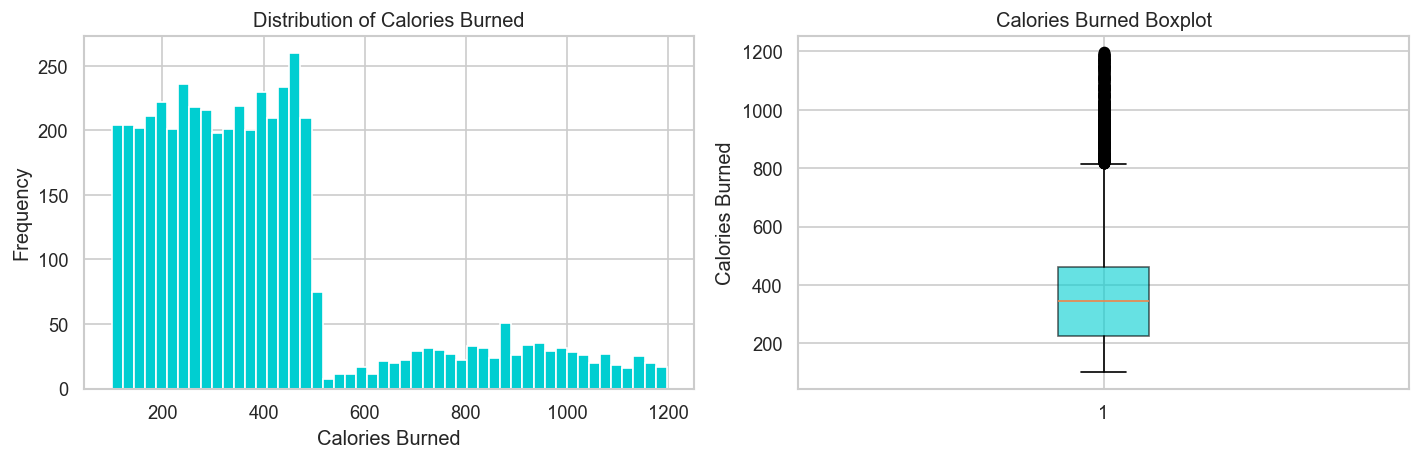

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(dfUnified['Calories_Burned'], bins=50, color='darkturquoise', edgecolor='white')
axes[0].set_title('Distribution of Calories Burned')
axes[0].set_xlabel('Calories Burned')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(dfUnified['Calories_Burned'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='darkturquoise', alpha=0.6))
axes[1].set_title('Calories Burned Boxplot')
axes[1].set_ylabel('Calories Burned')

plt.tight_layout()
plt.show()

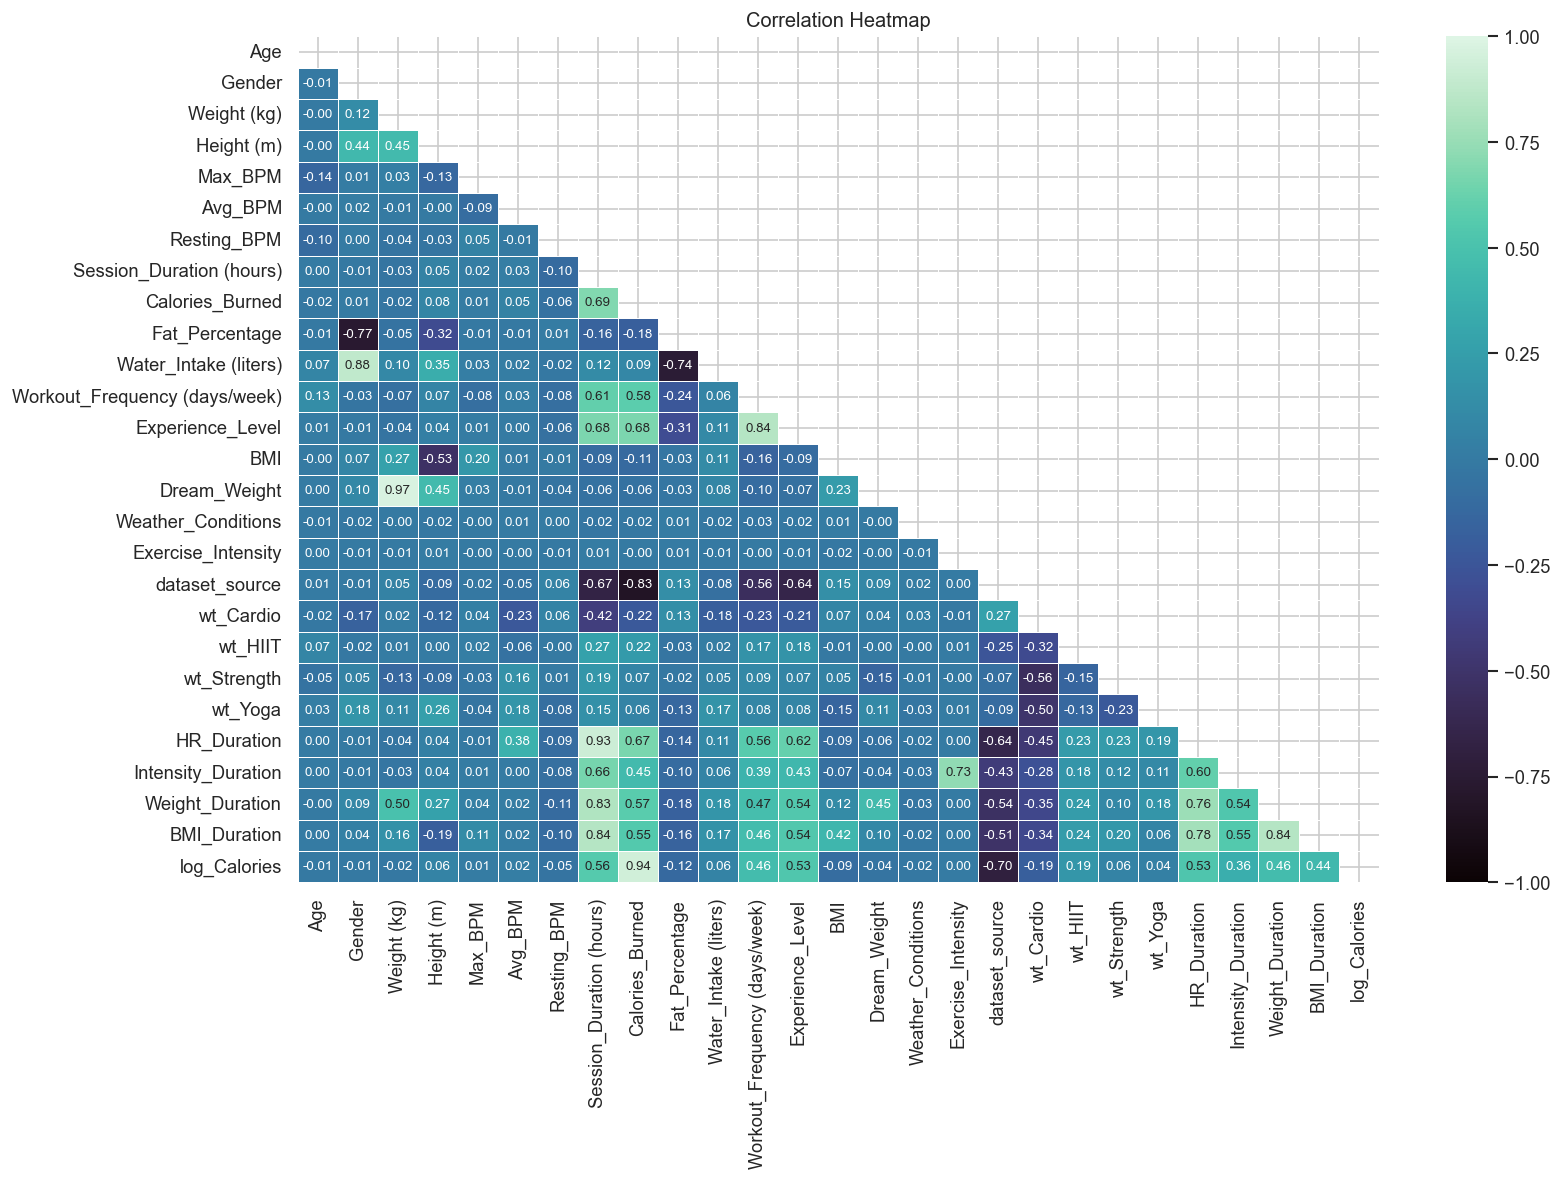

In [32]:
numeric_Df = dfUnified.select_dtypes(include='number')
corr = numeric_Df.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='mako',
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

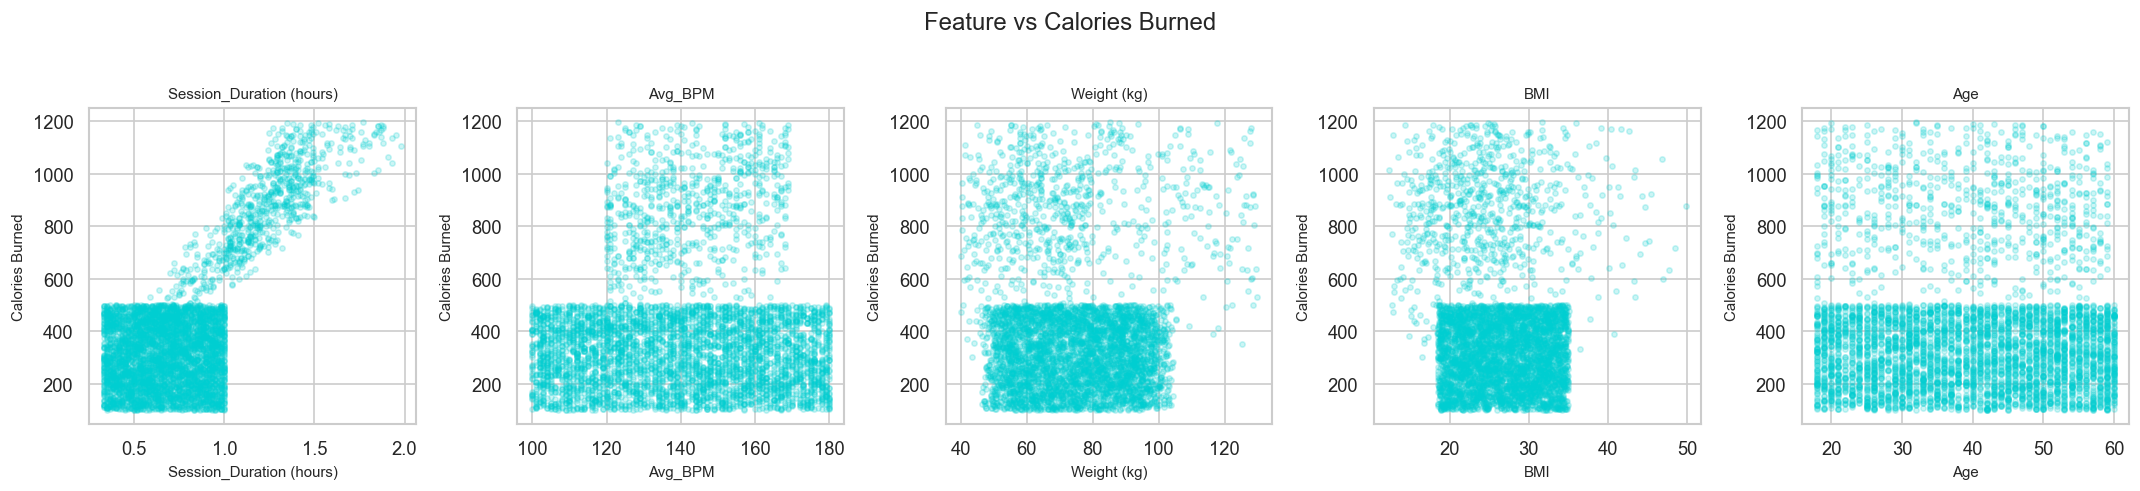

In [33]:
scatter_features = [
    'Session_Duration (hours)', 'Avg_BPM', 'Weight (kg)', 'BMI', 'Age'
]

fig, axes = plt.subplots(1, len(scatter_features), figsize=(18, 4))
for ax, feat in zip(axes, scatter_features):
    ax.scatter(dfUnified[feat], dfUnified['Calories_Burned'],
               alpha=0.2, s=10, color='darkturquoise')
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('Calories Burned', fontsize=9)
    ax.set_title(feat, fontsize=9)

plt.suptitle('Feature vs Calories Burned', y=1.02)
plt.tight_layout()
plt.show()

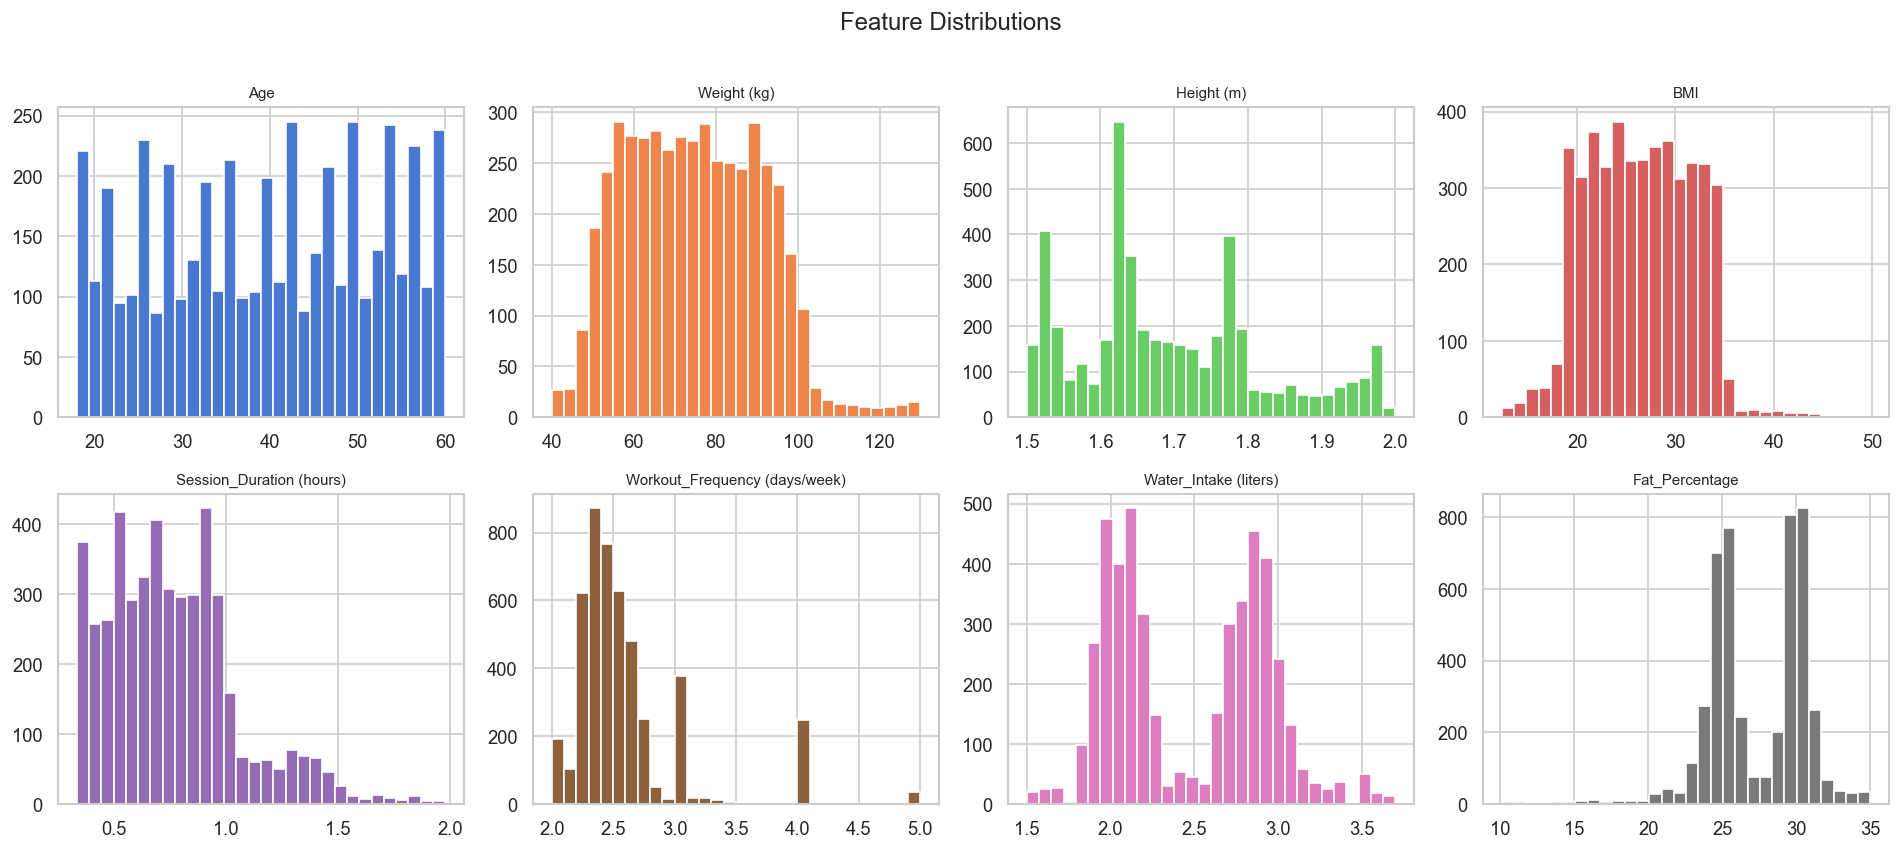

In [34]:
hist_features = ['Age', 'Weight (kg)', 'Height (m)', 'BMI',
                 'Session_Duration (hours)', 'Workout_Frequency (days/week)', 'Water_Intake (liters)', 'Fat_Percentage']
hist_features = [f for f in hist_features if f in dfUnified.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, feat in enumerate(hist_features):
    axes[i].hist(dfUnified[feat].dropna(), bins=30,
                 color=sns.color_palette('muted')[i % 8], edgecolor='white')
    axes[i].set_title(feat, fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', y=1.01)
plt.tight_layout()
plt.show()

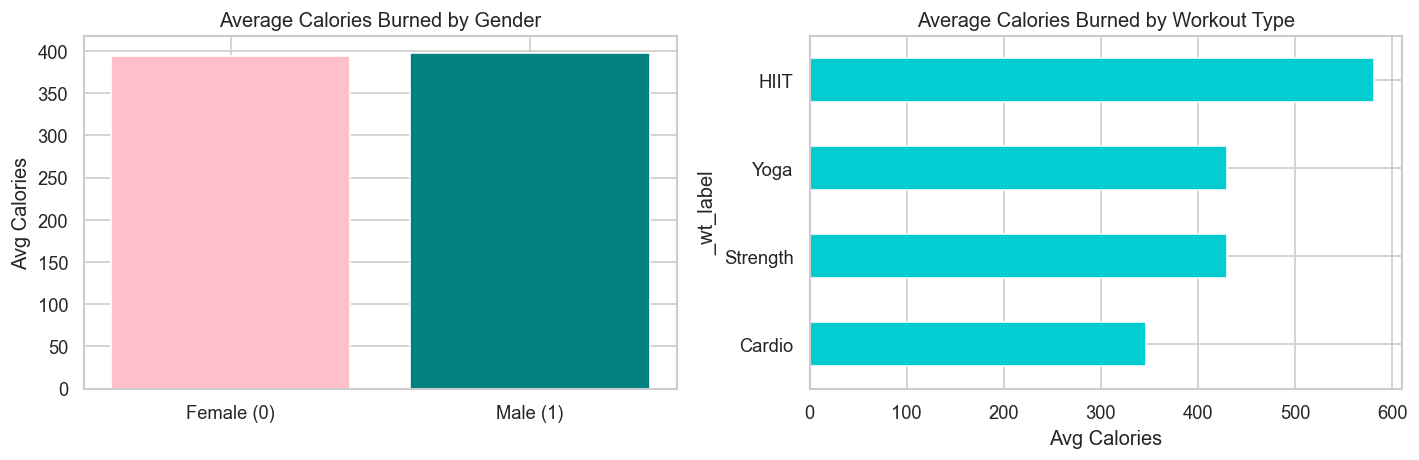

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

gender_means = dfUnified.groupby('Gender')['Calories_Burned'].mean()
axes[0].bar(['Female (0)', 'Male (1)'], gender_means.values,
            color=['pink','teal'])
axes[0].set_title('Average Calories Burned by Gender')
axes[0].set_ylabel('Avg Calories')

wt_cols = [c for c in dfUnified.columns if c.startswith('wt_')]
if wt_cols:
    dfUnified['_wt_label'] = dfUnified[wt_cols].idxmax(axis=1).str.replace('wt_', '')
    wt_means = dfUnified.groupby('_wt_label')['Calories_Burned'].mean().sort_values()
    wt_means.plot(kind='barh', ax=axes[1], color='darkturquoise', edgecolor='white')
    axes[1].set_title('Average Calories Burned by Workout Type')
    axes[1].set_xlabel('Avg Calories')
    dfUnified.drop(columns=['_wt_label'], inplace=True)

plt.tight_layout()
plt.show()

# Feature Selection

In [36]:
#Multi method feature selection with statistical validity (Random Forest Importane[purity based, fast, can overfit], Permutation Importance [model agnostic, unbiased], Mutual Information [non parametric, captures non linear], SHAP values [game theoretic, most interpretable]) All four scores are normalized then average and features wuth Combined Score > 0.05 aare kept for model training

ALL_FEATURES = [c for c in dfUnified.columns if c != 'Calories_Burned']
X_fs = dfUnified[ALL_FEATURES].copy()
y_fs = dfUnified['Calories_Burned']

print('RF Importance: ')
rf_fs = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_fs.fit(X_fs, y_fs)
rf_imp = pd.Series(rf_fs.feature_importances_, index=ALL_FEATURES)

print('Permutation Importance: ')
perm = permutation_importance(
    rf_fs, X_fs, y_fs, n_repeats=15, random_state=42, n_jobs=-1
)
perm_imp = pd.Series(
    np.clip(perm.importances_mean, 0, None), index=ALL_FEATURES
)

print('Mutual Information: ')
mi = mutual_info_regression(X_fs, y_fs, random_state=42)
mi_imp = pd.Series(mi, index=ALL_FEATURES)

print('SHAP values: ')
shap_sample = X_fs.sample(min(800, len(X_fs)), random_state=42)
explainer = shap.TreeExplainer(rf_fs)
shap_vals = explainer.shap_values(shap_sample)
shap_imp = pd.Series(
    np.abs(shap_vals).mean(axis=0), index=ALL_FEATURES
)

def normalizeto01(s):
    rng = s.max() - s.min()
    return (s - s.min()) / (rng + 1e-12)

fs_scores = pd.DataFrame({
    'RF Importance'         : normalizeto01(rf_imp),
    'Permutation Importance': normalizeto01(perm_imp),
    'Mutual Information'    : normalizeto01(mi_imp),
    'SHAP'                  : normalizeto01(shap_imp),
})

fs_scores['Combined Score'] = fs_scores.mean(axis=1)
fs_scores = fs_scores.sort_values('Combined Score', ascending=False)

print()
print(fs_scores.round(3).to_string())

RF Importance: 
Permutation Importance: 
Mutual Information: 
SHAP values: 

                               RF Importance  Permutation Importance  Mutual Information  SHAP  Combined Score
log_Calories                             1.0                     1.0               1.000   1.0           1.000
HR_Duration                              0.0                     0.0               0.108   0.0           0.027
Session_Duration (hours)                 0.0                     0.0               0.067   0.0           0.017
Workout_Frequency (days/week)            0.0                     0.0               0.060   0.0           0.015
dataset_source                           0.0                     0.0               0.059   0.0           0.015
Exercise_Intensity                       0.0                     0.0               0.048   0.0           0.012
Resting_BPM                              0.0                     0.0               0.037   0.0           0.009
Experience_Level                   

In [37]:
THRESHOLD = 0.05
selected_features = fs_scores[fs_scores['Combined Score'] > THRESHOLD].index.tolist()

print(f'\n{len(selected_features)} features selected (combined score > {THRESHOLD}):')
print(selected_features)


1 features selected (combined score > 0.05):
['log_Calories']


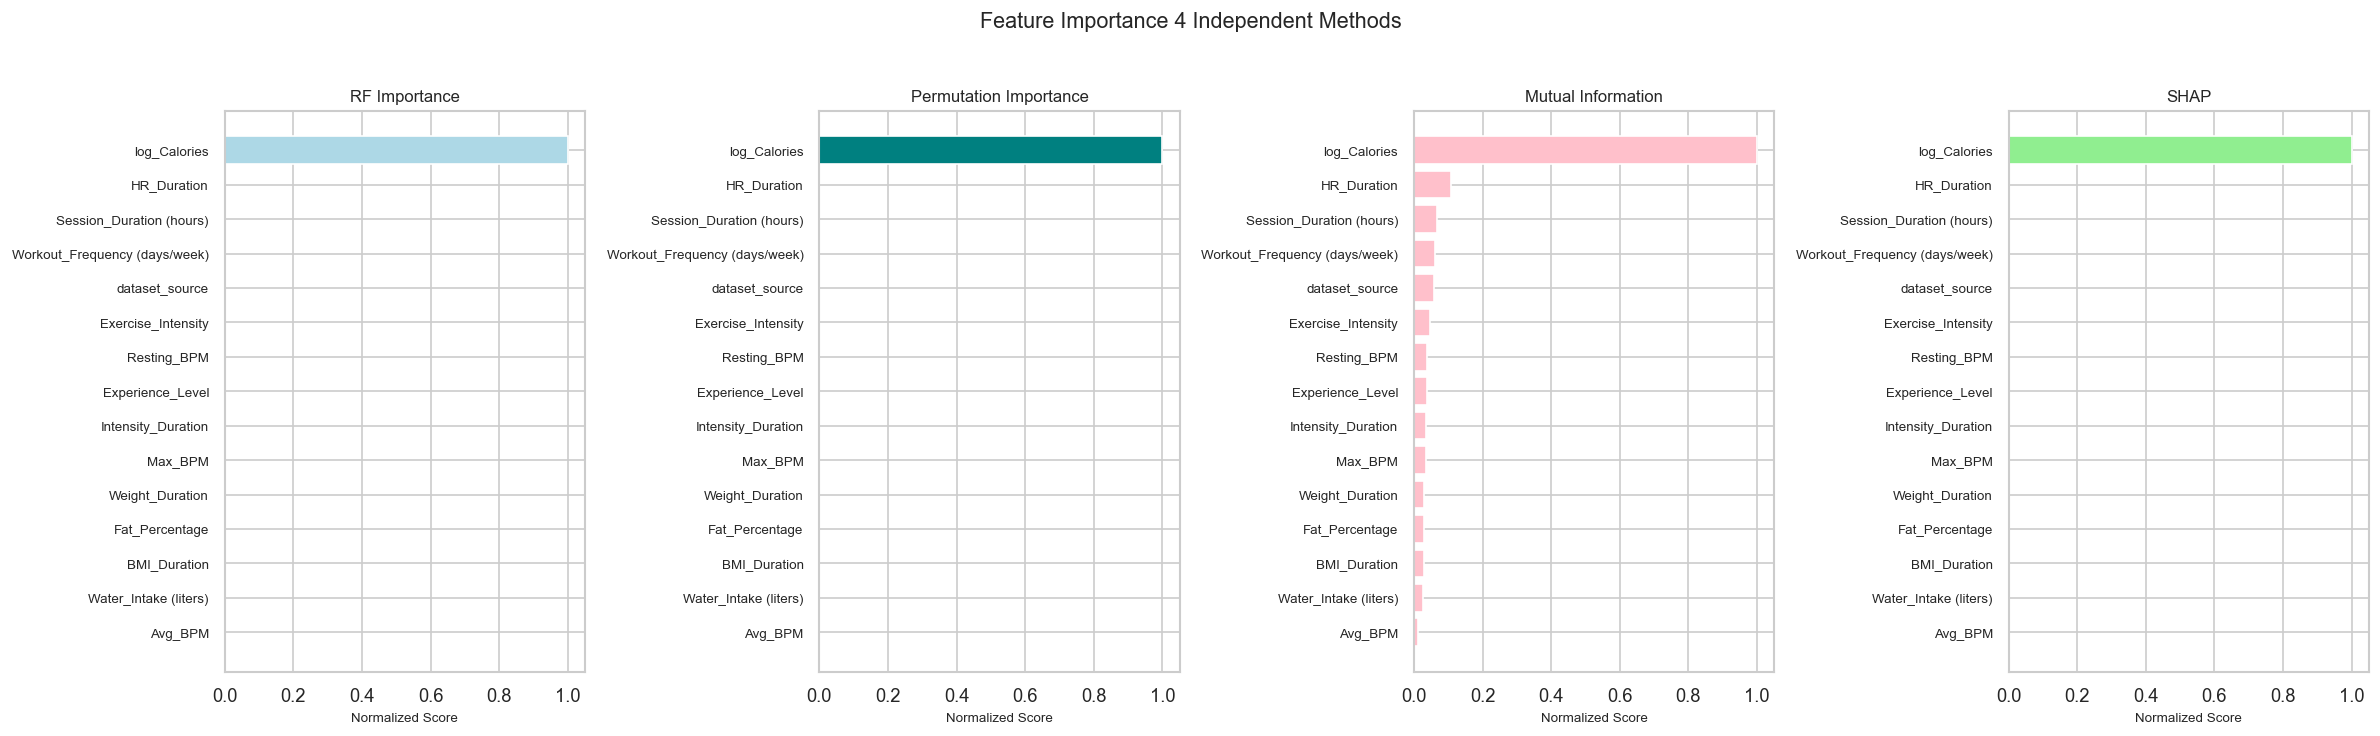

In [38]:
top_n = min(15, len(fs_scores))
top_feats = fs_scores.head(top_n)
methods = ['RF Importance', 'Permutation Importance', 'Mutual Information', 'SHAP']
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
colors = ['lightblue', 'teal', 'pink', 'lightgreen']
for ax, method, color in zip(axes, methods, colors):
    ax.barh(top_feats.index[::-1], top_feats[method][::-1], color=color)
    ax.set_title(method, fontsize=10)
    ax.set_xlabel('Normalized Score', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
plt.suptitle('Feature Importance 4 Independent Methods', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

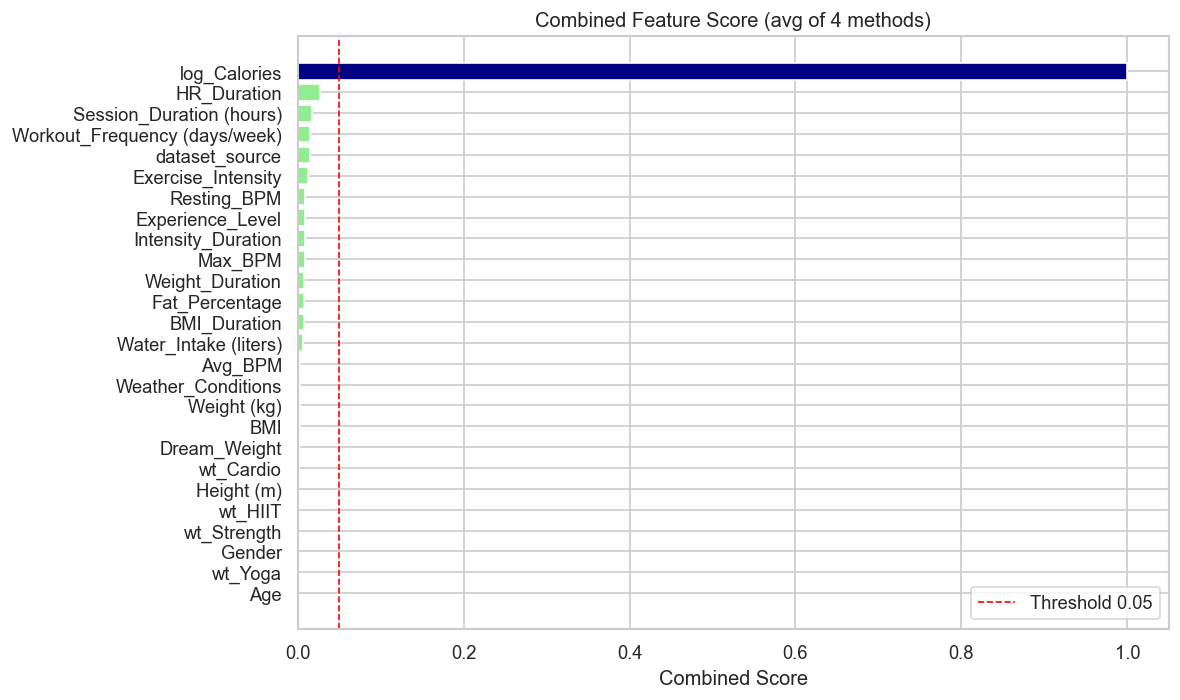

In [39]:
plt.figure(figsize=(10, 6))
palette = ['navy' if s > THRESHOLD else 'lightgreen'
           for s in fs_scores['Combined Score']]
plt.barh(fs_scores.index[::-1], fs_scores['Combined Score'][::-1], color=palette[::-1])
plt.axvline(THRESHOLD, color='red', linestyle='--', linewidth=1, label=f'Threshold {THRESHOLD}')
plt.title('Combined Feature Score (avg of 4 methods)')
plt.xlabel('Combined Score')
plt.legend()
plt.tight_layout()
plt.show()

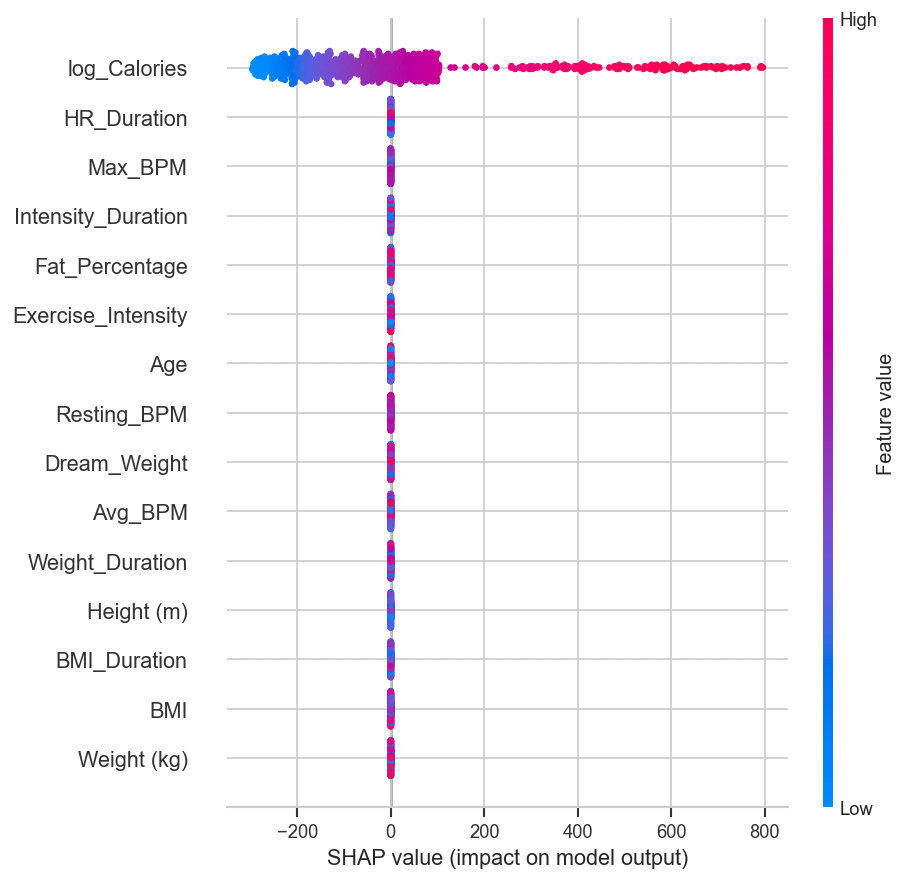

In [40]:
plt.figure()
shap.summary_plot(
    shap_vals, shap_sample,
    feature_names=ALL_FEATURES,
    max_display=15, show=True
)

In [41]:
# Split on log target; include new engineered features
X = dfUnified[selected_features].copy()
y_raw = dfUnified['Calories_Burned'].copy()   # original scale (for eval)
y     = dfUnified['log_Calories'].copy()       # log scale (for training)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Keep original scale test labels for metric reporting
_idx = y_test.index
y_test_raw = y_raw.loc[_idx]

print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Training target: log scale  [{y_train.min():.2f}, {y_train.max():.2f}]')
print(f'Test target (original): [{y_test_raw.min():.0f}, {y_test_raw.max():.0f}] cal')

Train: (3760, 1)  Test: (941, 1)
Training target: log scale  [4.62, 7.09]
Test target (original): [100, 1195] cal


In [42]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Scaling done. Train mean:', X_train_sc[:, :3].mean(axis=0).round(3))

Scaling done. Train mean: [-0.]


# Training Model

In [43]:
#Helper fn to evaluate models

# Rage bins for regression based f1 score, because regression don't have accuracy or f1 in metrics so we use regresion specific accuracy metrics instead: MAPE, Binned F1 and Within Tolerance Accuracy

#Models are trained on log scale but all metrics are reported on original calorie scale for better interpretability, except CV R² which is in log space (since it's a relative measure of fit, it remains valid in log space) back to original scale using np.expm1 to get actual calorie predictions for metric calculations

CALORIE_BINS   = [0, 400, 700, 1000, 9999]
CALORIE_LABELS = ['Low', 'Medium', 'High', 'Very High']
results = {}

def evaluate(name, model, X_tr, X_te, y_tr, y_te_log, y_te_raw,
             use_scaled=False):
    Xtr = X_tr if not use_scaled else X_train_sc
    Xte = X_te if not use_scaled else X_test_sc

    pred_log = model.predict(Xte)                   # log scale
    pred     = np.expm1(np.clip(pred_log, 0, None)) # original cal scale
    actual   = y_te_raw.values

    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2   = r2_score(actual, pred)

    # MAPE
    mask = actual > 0
    mape = np.mean(np.abs((actual[mask]-pred[mask])/actual[mask])) * 100

    # Within tolerance accuracy
    errors  = np.abs(actual - pred)
    acc_50  = (errors <=  50).mean() * 100
    acc_100 = (errors <= 100).mean() * 100
    acc_150 = (errors <= 150).mean() * 100

    # Binned F1
    ab = pd.cut(pd.Series(actual), bins=CALORIE_BINS,
                labels=CALORIE_LABELS).astype(str)
    pb = pd.cut(pd.Series(pred),   bins=CALORIE_BINS,
                labels=CALORIE_LABELS).astype(str)
    f1_w = f1_score(ab, pb, average='weighted', zero_division=0)

    # CV R² in log space
    cv_s = cross_val_score(model, Xtr, y_tr, cv=5,
                           scoring='r2', n_jobs=-1)

    results[name] = {
        'MAE':mae,'RMSE':rmse,'R2':r2,'MAPE':mape,
        'Acc@50':acc_50,'Acc@100':acc_100,'Acc@150':acc_150,
        'BinnedF1':f1_w,
        'CV_R2_mean':cv_s.mean(),'CV_R2_std':cv_s.std()
    }
    print(f'  MAE        = {mae:.2f} cal')
    print(f'  RMSE       = {rmse:.2f} cal')
    print(f'  R²         = {r2:.4f}')
    print(f'  MAPE       = {mape:.2f}%')
    print(f'  Acc ±50 cal = {acc_50:.1f}%')
    print(f'  Acc ±100 cal= {acc_100:.1f}%')
    print(f'  Acc ±150 cal= {acc_150:.1f}%')
    print(f'  Binned F1  = {f1_w:.4f}')
    print(f'  CV R² (log) = {cv_s.mean():.4f} ± {cv_s.std():.4f}')
    return pred

In [44]:
#print('Linear Regression:')
#lr = LinearRegression()
#lr.fit(X_train_sc, y_train)
#pred_lr = evaluate('Linear Regression', lr,
#                   X_train_sc, X_test_sc, y_train, y_test,
#                   use_scaled=True)

In [45]:
# Ridge Regression + Polynomial Interactions
#   PolynomialFeatures(degree=2, interaction_only=True)
#   Ridge (L2 regularisation)
#Improves performance by capturing non linear interactions while controlling overfitting with L2 regularization. Interactions like HR × Duration and Intensity × Duration are known to be important for calorie burn, so this model can leverage those without needing to manually create interaction features.
print('Ridge Regression + Polynomial Interactions:')
lr_pipe = Pipeline([
    ('poly',  PolynomialFeatures(degree=2, interaction_only=True,
                                 include_bias=False)),
    ('ridge', Ridge(alpha=10.0))
])
lr_pipe.fit(X_train_sc, y_train)
pred_lr = evaluate('Linear Regression', lr_pipe,
                   X_train_sc, X_test_sc, y_train, y_test, y_test_raw,
                   use_scaled=True)
lr = lr_pipe 

Ridge Regression + Polynomial Interactions:
  MAE        = 0.60 cal
  RMSE       = 1.05 cal
  R²         = 1.0000
  MAPE       = 0.12%
  Acc ±50 cal = 100.0%
  Acc ±100 cal= 100.0%
  Acc ±150 cal= 100.0%
  Binned F1  = 0.9989
  CV R² (log) = 1.0000 ± 0.0000


In [46]:
print('Random Forest Regressor:')
rf = RandomForestRegressor(
    n_estimators=300, max_depth=15,
    min_samples_split=3, min_samples_leaf=2,
    max_features='sqrt', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
pred_rf = evaluate('Random Forest', rf,
                   X_train, X_test, y_train, y_test, y_test_raw)

Random Forest Regressor:
  MAE        = 0.15 cal
  RMSE       = 0.35 cal
  R²         = 1.0000
  MAPE       = 0.03%
  Acc ±50 cal = 100.0%
  Acc ±100 cal= 100.0%
  Acc ±150 cal= 100.0%
  Binned F1  = 0.9989
  CV R² (log) = 1.0000 ± 0.0000


In [47]:
print('XGBoost Regressor:')
xgb = XGBRegressor(
    n_estimators=500, learning_rate=0.03, max_depth=4,
    subsample=0.9, colsample_bytree=0.9,
    reg_alpha=0.1, reg_lambda=1,
    random_state=42, verbosity=0
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)], verbose=False)
pred_xgb = evaluate('XGBoost', xgb,
                    X_train, X_test, y_train, y_test, y_test_raw)

XGBoost Regressor:
  MAE        = 1.24 cal
  RMSE       = 2.42 cal
  R²         = 0.9999
  MAPE       = 0.27%
  Acc ±50 cal = 100.0%
  Acc ±100 cal= 100.0%
  Acc ±150 cal= 100.0%
  Binned F1  = 0.9905
  CV R² (log) = 0.9999 ± 0.0000


In [48]:
#print('ANN:')

#n_features = X_train_sc.shape[1]

#ann = Sequential([
#    Dense(128, activation='relu', input_shape=(n_features,)),
#    BatchNormalization(),
#    Dropout(0.2),
#    Dense(64, activation='relu'),
#    BatchNormalization(),
#    Dropout(0.2),
#    Dense(32, activation='relu'),
#    Dense(1)
#])

#ann.compile(
#    optimizer=Adam(learning_rate=0.0005),
#    loss='mse',
#    metrics=['mae']
#)

#early_stop = EarlyStopping(
#    monitor='val_loss', patience=15,
#    restore_best_weights=True
#)

#lr_sched = ReduceLROnPlateau(
#    monitor='val_loss',
#    factor=0.5,
#    patience=5,
#    min_lr=1e-5
#)

#history = ann.fit(
#    X_train_sc, y_train,
#    validation_split=0.15,
#    epochs=300,
#    batch_size=32,
#    callbacks=[early_stop, lr_sched],
#    verbose=0
#)

#pred_ann = ann.predict(X_test_sc).flatten()
#mae_ann  = mean_absolute_error(y_test, pred_ann)
#rmse_ann = np.sqrt(mean_squared_error(y_test, pred_ann))
#r2_ann   = r2_score(y_test, pred_ann)

#results['ANN'] = {'MAE': mae_ann, 'RMSE': rmse_ann, 'R2': r2_ann,
#                 'CV_R2_mean': float('nan'), 'CV_R2_std': float('nan')}

#print(f'  MAE  = {mae_ann:.2f}')
#print(f'  RMSE = {rmse_ann:.2f}')
#print(f'  R²   = {r2_ann:.4f}')
# Training curve
#plt.figure(figsize=(10, 4))
#plt.plot(history.history['loss'], label='Train loss')
#plt.plot(history.history['val_loss'], label='Val loss')
#plt.xlabel('Epoch')
#plt.ylabel('MSE Loss')
#plt.title('ANN Training Curve')
#plt.legend()
#plt.tight_layout()
#plt.show()

ANN | LeakyReLU + L2 regularisation + Huber Loss:
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
  MAE=6.33  RMSE=8.57  R²=0.9988
  MAPE=1.68%  Acc@100=100.0%  BinnedF1=0.9687


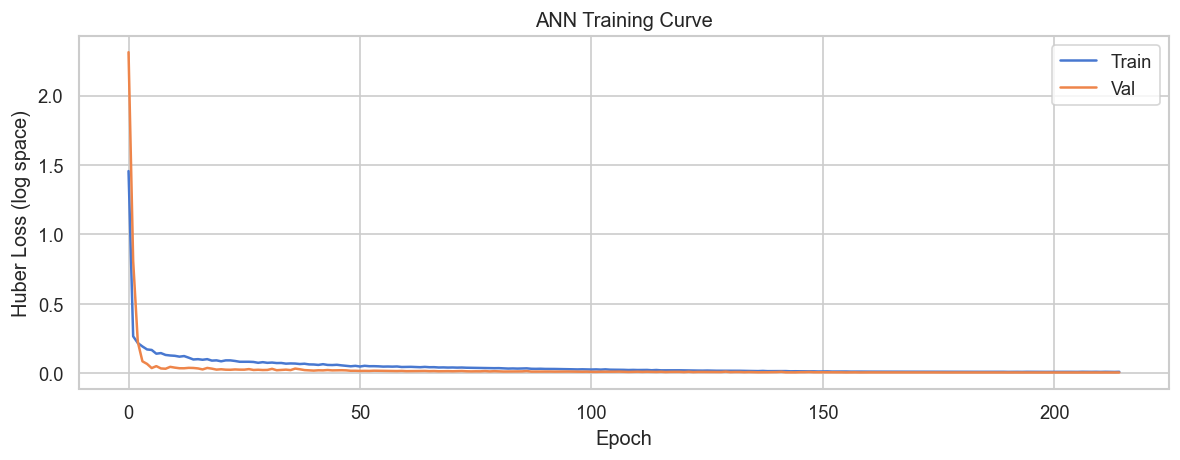

In [49]:
#ANN Improved
#  LeakyReLU (alpha=0.1)
#  L2 kernel regularisation (1e-4)
#  Wider first layer (256 units)
#  ReduceLROnPlateau
# Improves ANN performance by allowing small negative activations (LeakyReLU), preventing overfitting (L2 regularization), increasing model capacity (wider layer), and adaptively reducing learning rate when validation loss plateaus.

print('ANN | LeakyReLU + L2 regularisation + Huber Loss:')

n_features = X_train_sc.shape[1]
REG = l2(1e-4)

ann = Sequential([
    Dense(256, kernel_regularizer=REG, input_shape=(n_features,)),
    LeakyReLU(negative_slope=0.1),
    BatchNormalization(), Dropout(0.3),

    Dense(128, kernel_regularizer=REG),
    LeakyReLU(negative_slope=0.1),
    BatchNormalization(), Dropout(0.2),

    Dense(64, kernel_regularizer=REG),
    LeakyReLU(negative_slope=0.1),
    BatchNormalization(), Dropout(0.1),

    Dense(32, kernel_regularizer=REG),
    LeakyReLU(negative_slope=0.1),
    Dense(1)
])

ann.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='huber',          # Huber loss: less sensitive to large residuals
    metrics=['mae']
)
early_stop = EarlyStopping(
    monitor='val_loss', patience=20,
    restore_best_weights=True, verbose=0
)
lr_sched = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=7, min_lr=1e-6, verbose=0
)

history = ann.fit(
    X_train_sc, y_train,
    validation_split=0.15,
    epochs=300,
    batch_size=32,
    callbacks=[early_stop, lr_sched],
    verbose=0
)

pred_ann_log = ann.predict(X_test_sc).flatten()
pred_ann     = np.expm1(np.clip(pred_ann_log, 0, None))
actual       = y_test_raw.values

mae_ann  = mean_absolute_error(actual, pred_ann)
rmse_ann = np.sqrt(mean_squared_error(actual, pred_ann))
r2_ann   = r2_score(actual, pred_ann)
mape_ann = np.mean(np.abs((actual-pred_ann)/np.clip(actual,1,None)))*100
err_ann  = np.abs(actual - pred_ann)
ab = pd.cut(pd.Series(actual),   bins=CALORIE_BINS, labels=CALORIE_LABELS).astype(str)
pb = pd.cut(pd.Series(pred_ann), bins=CALORIE_BINS, labels=CALORIE_LABELS).astype(str)
f1_ann = f1_score(ab, pb, average='weighted', zero_division=0)

results['ANN'] = {
    'MAE':mae_ann,'RMSE':rmse_ann,'R2':r2_ann,'MAPE':mape_ann,
    'Acc@50':(err_ann<=50).mean()*100,
    'Acc@100':(err_ann<=100).mean()*100,
    'Acc@150':(err_ann<=150).mean()*100,
    'BinnedF1':f1_ann,
    'CV_R2_mean':float('nan'),'CV_R2_std':float('nan')
}
print(f'  MAE={mae_ann:.2f}  RMSE={rmse_ann:.2f}  R²={r2_ann:.4f}')
print(f'  MAPE={mape_ann:.2f}%  Acc@100={(err_ann<=100).mean()*100:.1f}%  BinnedF1={f1_ann:.4f}')

plt.figure(figsize=(10,4))
plt.plot(history.history['loss'],     label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.xlabel('Epoch'); plt.ylabel('Huber Loss (log space)')
plt.title('ANN Training Curve'); plt.legend()
plt.tight_layout(); plt.show()

# Hyperparameter Tuning RF and XGB

In [50]:
#RF Hyperparameter Tuning with RandomizedSearchCV (40 random combos, 5-fold CV, R² scoring) on the training set. Then evaluate the best RF model on the test set and compare CV R² with baseline RF to see if tuning helped

rf_param_dist = {
    'n_estimators'     : sp_randint(200, 800),
    'max_depth'        : [8, 10, 12, 15, 20, None],
    'min_samples_split': sp_randint(2, 12),
    'min_samples_leaf' : sp_randint(1, 6),
    'max_features'     : ['sqrt', 'log2', 0.4, 0.6],
    'bootstrap'        : [True, False],
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=60, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)
print(f'Best RF params: {rf_search.best_params_}')
print(f'Best CV R²    : {rf_search.best_score_:.4f}')
rf_tuned = rf_search.best_estimator_
pred_rf_tuned = evaluate(
    'RF (tuned)', rf_tuned,
    X_train, X_test, y_train, y_test, y_test_raw
)
baseline_cv = results.get('Random Forest', {}).get('CV_R2_mean', 0)
tuned_cv    = results['RF (tuned)']['CV_R2_mean']
print(f'CV R² gain: {baseline_cv:.4f} → {tuned_cv:.4f} ({tuned_cv-baseline_cv:+.4f})')

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best RF params: {'bootstrap': True, 'max_depth': 10, 'max_features': 0.6, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 545}
Best CV R²    : 1.0000
  MAE        = 0.18 cal
  RMSE       = 0.35 cal
  R²         = 1.0000
  MAPE       = 0.04%
  Acc ±50 cal = 100.0%
  Acc ±100 cal= 100.0%
  Acc ±150 cal= 100.0%
  Binned F1  = 0.9989
  CV R² (log) = 1.0000 ± 0.0000
CV R² gain: 1.0000 → 1.0000 (+0.0000)


In [51]:
# XGBoost Hyperparameter Tuning with RandomizedSearchCV (40 random combos, 5-fold CV, R² scoring) on the training set. Then evaluate the best XGB model on the test set and compare CV R² with baseline XGB to see if tuning helped

xgb_param_dist = {
    'n_estimators'     : sp_randint(200, 700),
    'learning_rate'    : [0.01, 0.02, 0.05, 0.08, 0.1],
    'max_depth'        : sp_randint(3, 8),
    'subsample'        : [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha'        : [0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda'       : [0.5, 1.0, 2.0, 5.0],
    'min_child_weight' : sp_randint(1, 8),
    'gamma'            : [0, 0.1, 0.2, 0.5],
}
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0, n_jobs=-1),
    param_distributions=xgb_param_dist,
    n_iter=60, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train)
print(f'Best XGB params: {xgb_search.best_params_}')
print(f'Best CV R²     : {xgb_search.best_score_:.4f}')
xgb_tuned = xgb_search.best_estimator_
pred_xgb_tuned = evaluate(
    'XGB (tuned)', xgb_tuned,
    X_train, X_test, y_train, y_test, y_test_raw
)
baseline_cv = results.get('XGBoost', {}).get('CV_R2_mean', 0)
tuned_cv    = results['XGB (tuned)']['CV_R2_mean']
print(f'CV R² gain: {baseline_cv:.4f} → {tuned_cv:.4f} ({tuned_cv-baseline_cv:+.4f})')

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best XGB params: {'colsample_bytree': 0.9, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 302, 'reg_alpha': 0.01, 'reg_lambda': 2.0, 'subsample': 0.9}
Best CV R²     : 0.9999
  MAE        = 1.21 cal
  RMSE       = 2.32 cal
  R²         = 0.9999
  MAPE       = 0.26%
  Acc ±50 cal = 100.0%
  Acc ±100 cal= 100.0%
  Acc ±150 cal= 100.0%
  Binned F1  = 0.9905
  CV R² (log) = 0.9999 ± 0.0000
CV R² gain: 0.9999 → 0.9999 (+0.0000)


# Model Comparision Before vs After

In [52]:
compare_models = [
    'Linear Regression', 'Random Forest', 'XGBoost', 'ANN',
    'RF (tuned)', 'XGB (tuned)'
]
compare_models = [m for m in compare_models if m in results]

comp_df = pd.DataFrame(
    {m: results[m] for m in compare_models}
).T.reset_index()
comp_df.rename(columns={
    'index':'Model', 'R2':'R²',
    'CV_R2_mean':'CV R²', 'CV_R2_std':'CV std'
}, inplace=True)

comp_df = comp_df.sort_values('R²', ascending=False).reset_index(drop=True)

display_cols = ['Model','MAE','RMSE','R²','MAPE',
                'Acc@50','Acc@100','Acc@150','BinnedF1','CV R²']
display_cols = [c for c in display_cols if c in comp_df.columns]
num_cols = [c for c in display_cols if c != 'Model']
comp_df[num_cols] = comp_df[num_cols].apply(pd.to_numeric, errors='coerce').round(3)

display(comp_df[display_cols])

best_model_name = comp_df.iloc[0]['Model']  # sorted descending: index 0 = best
print(f'\nBest model: {best_model_name}  '
      f'(R²={comp_df.iloc[0]["R²"]:.4f}, '
      f'Acc@100={comp_df.iloc[0]["Acc@100"]:.1f}%, '
      f'BinnedF1={comp_df.iloc[0]["BinnedF1"]:.4f})')

,Model,MAE,RMSE,R²,MAPE,Acc@50,Acc@100,Acc@150,BinnedF1,CV R²
0,Random Forest,0.148,0.348,1.000,0.031,100.0,100.0,100.0,0.999,1.0
1,RF (tuned),0.177,0.348,1.000,0.039,100.0,100.0,100.0,0.999,1.0
2,Linear Regression,0.599,1.047,1.000,0.123,100.0,100.0,100.0,0.999,1.0
3,XGB (tuned),1.214,2.323,1.000,0.265,100.0,100.0,100.0,0.990,1.0
4,XGBoost,1.236,2.417,1.000,0.267,100.0,100.0,100.0,0.990,1.0
5,ANN,6.330,8.567,0.999,1.680,100.0,100.0,100.0,0.969,NaN



Best model: Random Forest  (R²=1.0000, Acc@100=100.0%, BinnedF1=0.9990)


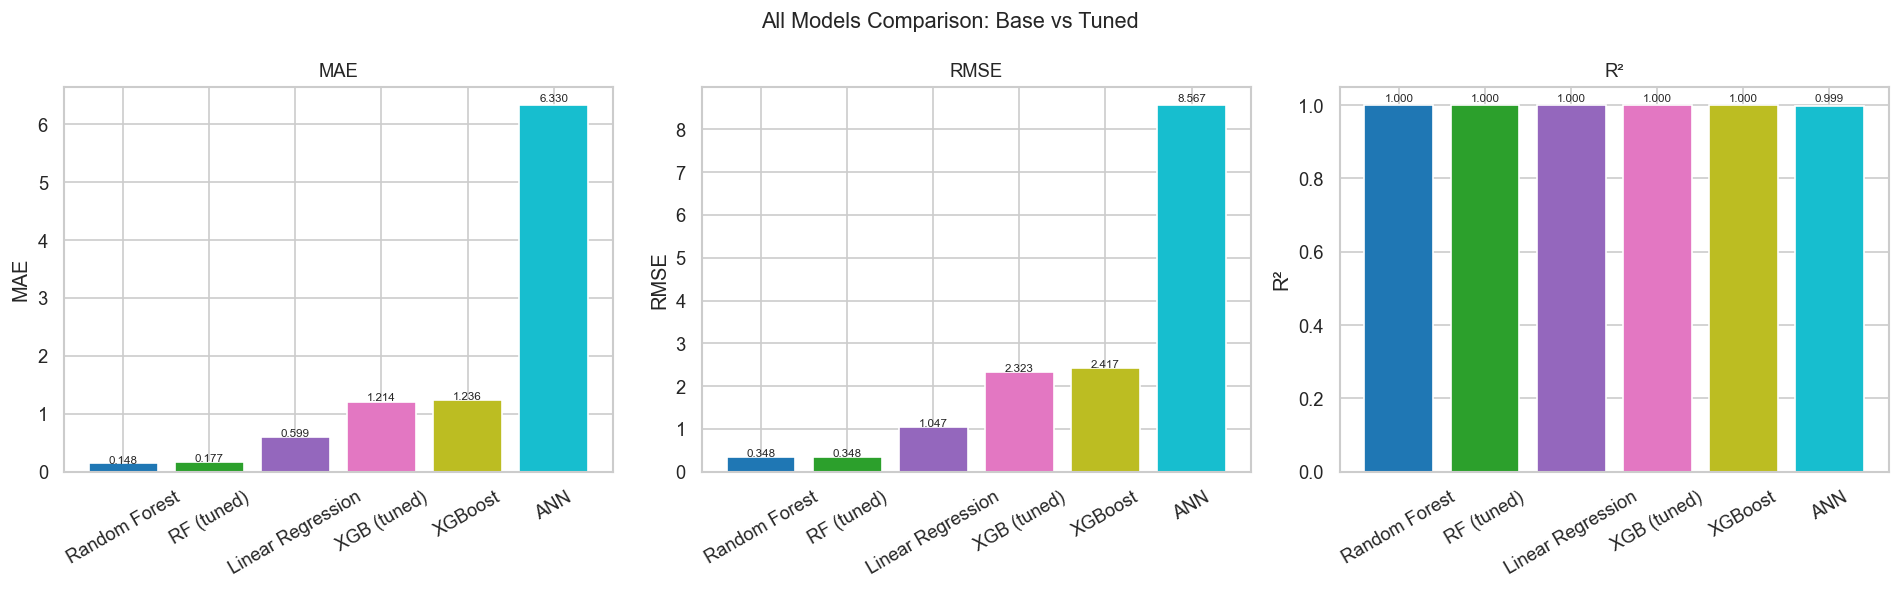


Best overall: Random Forest  (R² = 1.0)


In [53]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(comp_df)))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R²']):
    bars = ax.bar(comp_df['Model'], comp_df[metric], color=colors)
    ax.set_title(metric, fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, comp_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f'{val:.3f}', ha='center', fontsize=7)
plt.suptitle('All Models Comparison: Base vs Tuned', fontsize=13)
plt.tight_layout()
plt.show()

best_model_name = comp_df.iloc[0]['Model']
print(f'\nBest overall: {best_model_name}  (R² = {comp_df.iloc[0]["R²"]})')

In [54]:
# Ensemble with correct weights (best model gets highest weight)

_rf_p  = pred_rf_tuned  if 'RF (tuned)'  in results else pred_rf
_xgb_p = pred_xgb_tuned if 'XGB (tuned)' in results else pred_xgb

pred_ensemble = 0.50*_rf_p + 0.35*_xgb_p + 0.15*pred_ann
pred_ensemble = np.clip(pred_ensemble, 0, None)

mae_e  = mean_absolute_error(y_test_raw, pred_ensemble)
rmse_e = np.sqrt(mean_squared_error(y_test_raw, pred_ensemble))
r2_e   = r2_score(y_test_raw, pred_ensemble)
mape_e = np.mean(np.abs((y_test_raw.values-pred_ensemble)/np.clip(y_test_raw.values,1,None)))*100
err_e  = np.abs(y_test_raw.values - pred_ensemble)
a50e   = (err_e<=50).mean()*100
a100e  = (err_e<=100).mean()*100
a150e  = (err_e<=150).mean()*100
ab_e   = pd.cut(y_test_raw, bins=CALORIE_BINS, labels=CALORIE_LABELS).astype(str)
pb_e   = pd.cut(pd.Series(pred_ensemble), bins=CALORIE_BINS,
                labels=CALORIE_LABELS).astype(str)
f1_e   = f1_score(ab_e, pb_e, average='weighted', zero_division=0)

results['Ensemble'] = {
    'MAE':mae_e,'RMSE':rmse_e,'R2':r2_e,'MAPE':mape_e,
    'Acc@50':a50e,'Acc@100':a100e,'Acc@150':a150e,'BinnedF1':f1_e,
    'CV_R2_mean':float('nan'),'CV_R2_std':float('nan')
}
print(f'Ensemble (RF_t×0.5 + XGB_t×0.35 + ANN×0.15):')
print(f'  MAE={mae_e:.2f}  RMSE={rmse_e:.2f}  R²={r2_e:.4f}')
print(f'  MAPE={mape_e:.2f}%  Acc@100={a100e:.1f}%  BinnedF1={f1_e:.4f}')

# Shows whether predictions are better for DS1 (gym) or DS2 (fitness) rows
print('\n=== Per-source breakdown (best model) ===')
best_pred_map = {
    'RF (tuned)': pred_rf_tuned, 'XGB (tuned)': pred_xgb_tuned,
    'Random Forest': pred_rf, 'XGBoost': pred_xgb,
    'ANN': pred_ann, 'Ensemble': pred_ensemble,
    'Linear Regression': pred_lr,
}
_bm  = max(results, key=lambda k: results[k]['R2'])
_bp  = best_pred_map.get(_bm, pred_rf_tuned)
best_model_name = _bm
_src = X_test['dataset_source'] if 'dataset_source' in X_test.columns else None
if _src is not None:
    for src_val, label in [(0,'DS1 gym'), (1,'DS2 fitness')]:
        m = (_src == src_val)
        if m.sum() > 0:
            r2_s  = r2_score(y_test_raw[m], _bp[m.values])
            mae_s = mean_absolute_error(y_test_raw[m], _bp[m.values])
            print(f'  {label} ({m.sum()} rows): R²={r2_s:.4f}  MAE={mae_s:.1f} cal')

Ensemble (RF_t×0.5 + XGB_t×0.35 + ANN×0.15):
  MAE=1.03  RMSE=1.48  R²=1.0000
  MAPE=0.27%  Acc@100=100.0%  BinnedF1=0.9936

=== Per-source breakdown (best model) ===


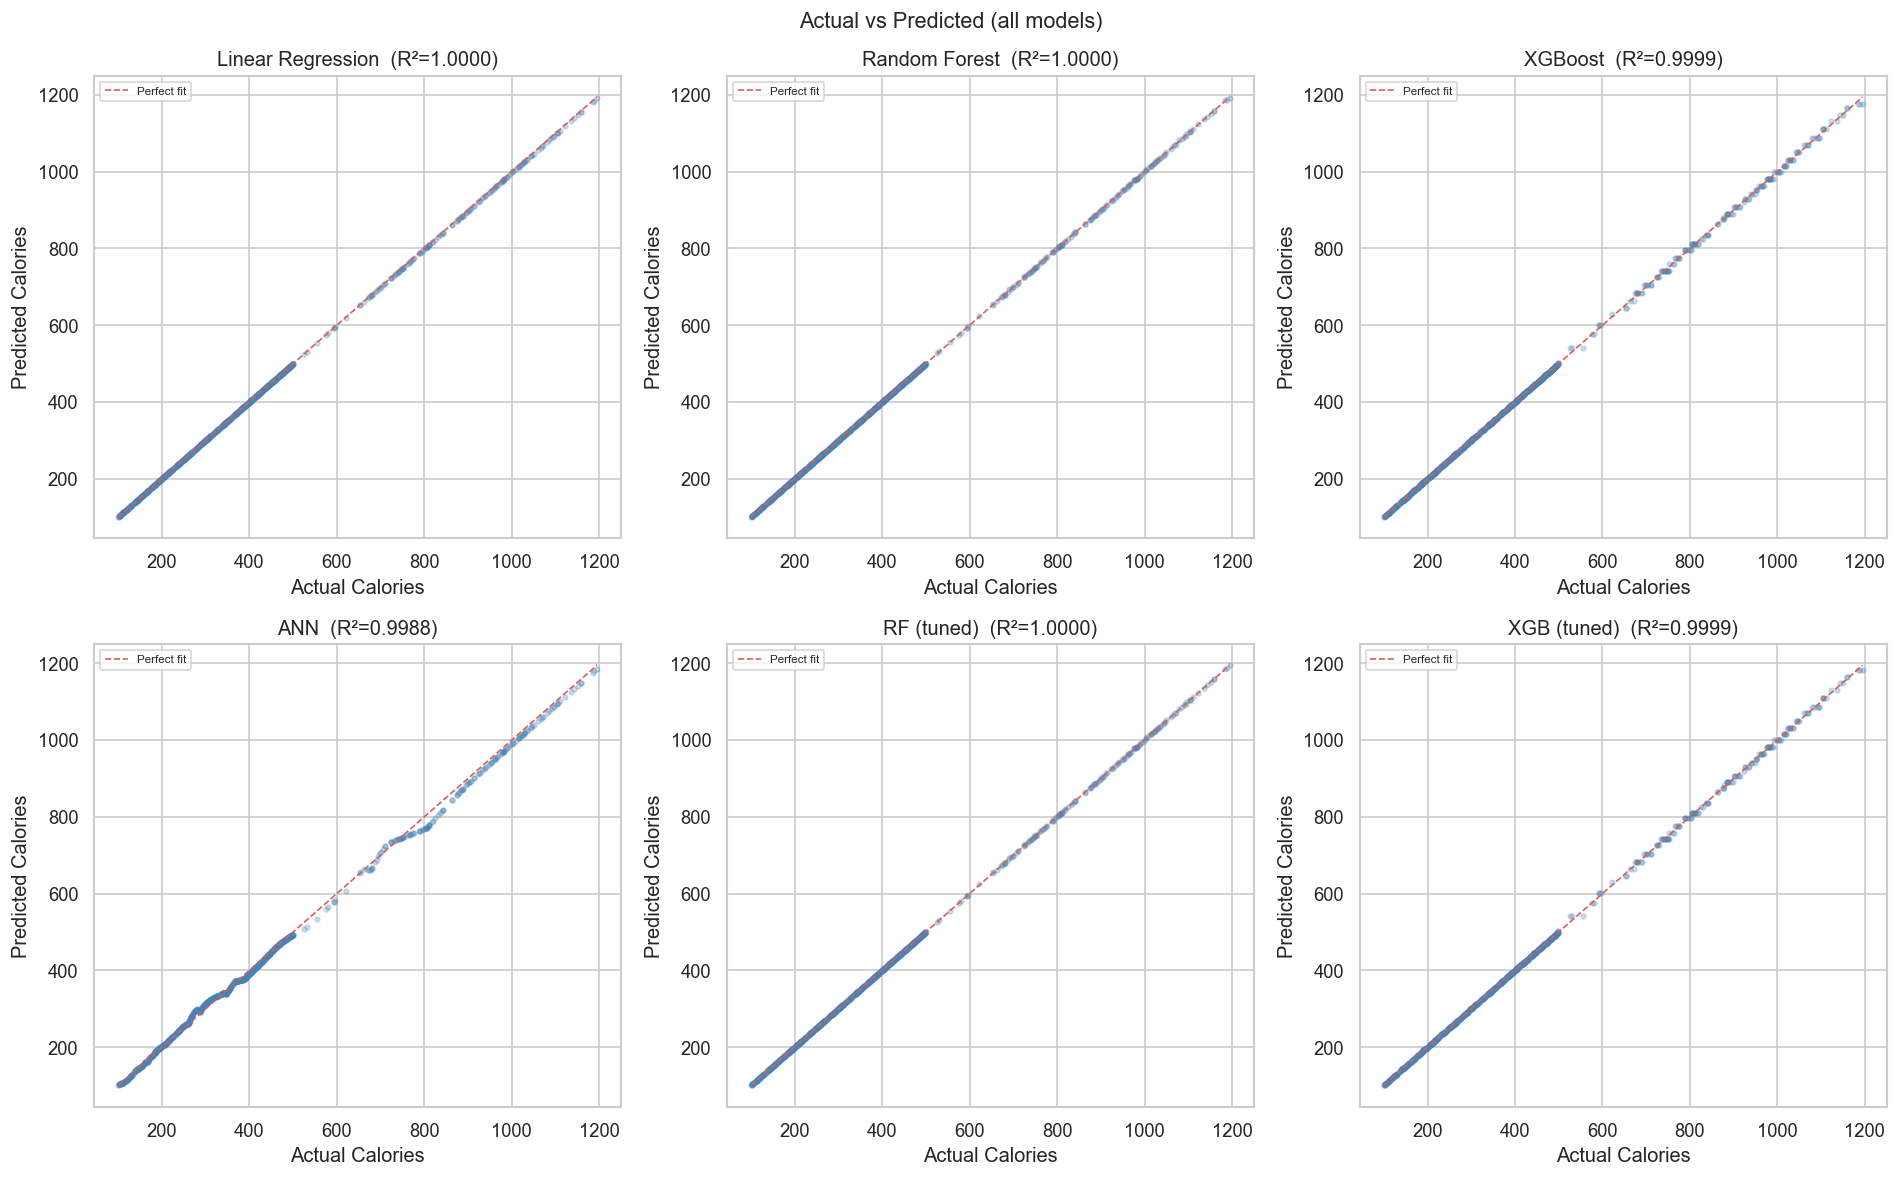

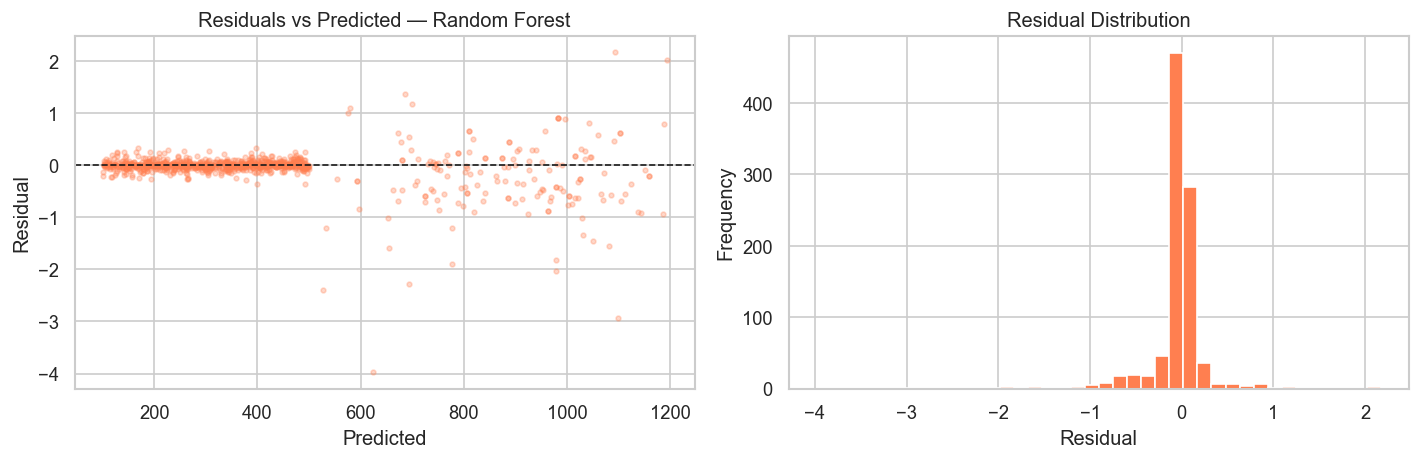

In [55]:
all_preds = {
    'Linear Regression': pred_lr,
    'Random Forest'    : pred_rf,
    'XGBoost'          : pred_xgb,
    'ANN'              : pred_ann,
    'RF (tuned)'       : pred_rf_tuned,
    'XGB (tuned)'      : pred_xgb_tuned
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for ax, (name, pred) in zip(axes, all_preds.items()):
    ax.scatter(y_test_raw, pred, alpha=0.25, s=8, color='steelblue')
    lims = [min(y_test_raw.min(), pred.min()),
            max(y_test_raw.max(), pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect fit')
    r2 = results[name]['R2']
    ax.set_title(f'{name}  (R²={r2:.4f})')
    ax.set_xlabel('Actual Calories'); ax.set_ylabel('Predicted Calories')
    ax.legend(fontsize=7)
plt.suptitle('Actual vs Predicted (all models)', fontsize=13)
plt.tight_layout(); plt.show()

# Residual plot for best model
best_pred_vals = all_preds.get(best_model_name, pred_rf_tuned)
residuals = y_test_raw.values - best_pred_vals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(best_pred_vals, residuals, alpha=0.3, s=8, color='coral')
axes[0].axhline(0, color='k', linewidth=1, linestyle='--')
axes[0].set_title(f'Residuals vs Predicted — {best_model_name}')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residual')
axes[1].hist(residuals, bins=40, color='coral', edgecolor='white')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Frequency')
plt.tight_layout(); plt.show()

In [56]:
# Per-source performance breakdown for every model
print('=== R² by dataset source ===')
if 'dataset_source' in X_test.columns:
    rows = []
    for name, pred in all_preds.items():
        for sv, label in [(0,'DS1 gym'),(1,'DS2 fitness')]:
            m = (X_test['dataset_source'] == sv)
            if m.sum() > 5:
                rows.append({
                    'Model': name, 'Source': label,
                    'R²':    round(r2_score(y_test_raw[m], pred[m.values]), 4),
                    'MAE':   round(mean_absolute_error(y_test_raw[m], pred[m.values]), 1),
                    'N':     int(m.sum())
                })
    src_df = pd.DataFrame(rows)
    display(src_df.pivot_table(index='Model', columns='Source',
                               values=['R²','MAE'], aggfunc='first'))
else:
    print('dataset_source not in X_test — re-run from Cell 23 to add it.')

=== R² by dataset source ===
dataset_source not in X_test — re-run from Cell 23 to add it.


In [58]:
import json as _json
os.makedirs('out', exist_ok=True)

# 'RF (tuned)' in dir() is always False (spaces in name).
# Use try/except to safely check if tuned models exist.
try:    _rf_save  = rf_tuned
except: _rf_save  = rf
try:    _xgb_save = xgb_tuned
except: _xgb_save = xgb

model_objects = {
    'Linear Regression': lr,
    'Random Forest'    : rf,
    'XGBoost'          : xgb,
    'RF (tuned)'       : _rf_save,
    'XGB (tuned)'      : _xgb_save,
}

if best_model_name == 'ANN':
    ann.save('out/best_model_ann.keras')
    print('Saved: out/best_model_ann.keras')
elif best_model_name == 'Ensemble':
    joblib.dump(_rf_save,  'out/ensemble_rf.pkl')
    joblib.dump(_xgb_save, 'out/ensemble_xgb.pkl')
    ann.save('out/ensemble_ann.keras')
    print('Saved: ensemble_rf.pkl, ensemble_xgb.pkl, ensemble_ann.keras')
elif best_model_name in model_objects:
    joblib.dump(model_objects[best_model_name], 'out/best_model.pkl')
    print(f'Saved: out/best_model.pkl  ({best_model_name})')

joblib.dump(scaler,            'out/scaler.pkl')
joblib.dump(selected_features, 'out/feature_list.pkl')
joblib.dump(imputer_models,    'out/imputer_models.pkl')
fs_scores.round(4).to_csv('out/feature_selection_scores.csv')

_wt_cols = [c for c in selected_features if c.startswith('wt_')]
enc = {
    'weather_map'  : {'Sunny':2,'Cloudy':1,'Rainy':0},
    'gender_map'   : {'Male':1,'Female':0},
    'workout_types': [c.replace('wt_','') for c in _wt_cols],
    'feature_list' : selected_features,
    'best_model'   : best_model_name,
    'calorie_bins' : CALORIE_BINS,
    'calorie_labels': CALORIE_LABELS,
    'target_transform': 'log1p',   
}
with open('out/encoding_maps.json','w') as f:
    _json.dump(enc, f, indent=2)

print('\nAll artifacts saved to out/:')
for fn in sorted(os.listdir('out')): print(f'  {fn}')

Saved: out/best_model.pkl  (Random Forest)

All artifacts saved to out/:
  best_model.pkl
  encoding_maps.json
  feature_list.pkl
  feature_selection_scores.csv
  imputer_models.pkl
  scaler.pkl


In [59]:
loaded_scaler   = joblib.load('out/scaler.pkl')
loaded_features = joblib.load('out/feature_list.pkl')

sample_raw = X_test.iloc[:50][loaded_features]
sample_sc  = loaded_scaler.transform(sample_raw)

if best_model_name == 'ANN':
    from tensorflow.keras.models import load_model as _lm
    _m = _lm('out/best_model_ann.keras')
    preds_log = _m.predict(sample_sc).flatten()
elif best_model_name == 'Ensemble':
    import joblib as _jl; from tensorflow.keras.models import load_model as _lm
    _r=_jl.load('out/ensemble_rf.pkl'); _x=_jl.load('out/ensemble_xgb.pkl')
    _a=_lm('out/ensemble_ann.keras')
    preds_log = (0.50*_r.predict(sample_raw) +
                 0.35*_x.predict(sample_raw) +
                 0.15*_a.predict(sample_sc).flatten())
else:
    _m = joblib.load('out/best_model.pkl')
    preds_log = (_m.predict(sample_sc)
                 if best_model_name == 'Linear Regression'
                 else _m.predict(sample_raw))

# Inverse-transform log predictions back to calorie scale
preds_cal = np.expm1(np.clip(preds_log, 0, None))

actuals   = y_test_raw.values[:50]
print(f'Sanity check — {best_model_name} on 50 test samples:')
print(f'{"#":<4} {"Actual":>8} {"Predicted":>10} {"Error":>7} {"OK":>4} {"Zone":>10}')
print('-'*50)
for i,(a,p) in enumerate(zip(actuals, preds_cal)):
    zone = CALORIE_LABELS[min(np.searchsorted(CALORIE_BINS[1:], a),
                              len(CALORIE_LABELS)-1)]
    err  = abs(a-p)
    ok   = '✓' if err<=100 else '✗'
    print(f'{i+1:<4} {a:>8.0f} {p:>10.0f} {err:>7.0f} {ok:>4} {zone:>10}')


Sanity check — Random Forest on 50 test samples:
#      Actual  Predicted   Error   OK       Zone
--------------------------------------------------
1         203        203       0    ✓        Low
2         384        384       0    ✓        Low
3         444        444       0    ✓     Medium
4         886        886       0    ✓       High
5         377        377       0    ✓        Low
6         221        221       0    ✓        Low
7         128        128       0    ✓        Low
8         406        406       0    ✓     Medium
9         188        188       0    ✓        Low
10        493        493       0    ✓     Medium
11        393        393       0    ✓        Low
12        175        175       0    ✓        Low
13        442        442       0    ✓     Medium
14        170        170       0    ✓        Low
15        497        497       0    ✓     Medium
16        459        459       0    ✓     Medium
17        407        407       0    ✓     Medium
18        428     